In [1]:
import sqlite3
rows = [
    ("2025-09-01", "Widget",       10, 2.5),   # revenue 25.0
    ("2025-09-02", "Gadget",        5, 5.0),   # revenue 25.0
    ("2025-09-03", "Widget",        3, 2.5),   # revenue 7.5
    ("2025-09-04", "Doohickey",     7, 1.5),   # revenue 10.5
    ("2025-09-05", "Gadget",        2, 5.0),   # revenue 10.0
    ("2025-09-06", "Doohickey",     1, 1.5),   # revenue 1.5
    ("2025-09-06", "Widget",        2, 2.5),   # revenue 5.0
    ("2025-09-07", "Thingamajig",   4, 3.0),   # revenue 12.0
    ("2025-09-08", "Gadget",        8, 5.0)    # revenue 40.0
]

conn = sqlite3.connect("sales_data.db")
cur = conn.cursor()
cur.execute("""
CREATE TABLE IF NOT EXISTS sales (
    id INTEGER PRIMARY KEY AUTOINCREMENT,
    date TEXT,
    product TEXT,
    quantity INTEGER,
    price REAL
)
""")
cur.executemany("INSERT INTO sales (date, product, quantity, price) VALUES (?, ?, ?, ?)", rows)
conn.commit()
conn.close()
print("Created sales_data.db with sample rows.")

Created sales_data.db with sample rows.


Overall totals:
 total_quantity  total_revenue
             42          136.5

Per-product summary:
    product  total_qty  revenue
     Gadget         15     75.0
     Widget         15     37.5
Thingamajig          4     12.0
  Doohickey          8     12.0


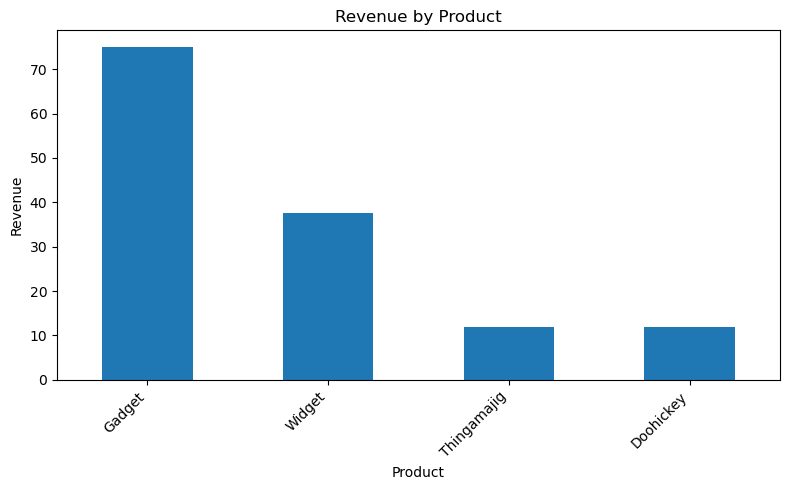

In [4]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
# 1) Connect to DB
conn = sqlite3.connect("sales_data.db")
# 2) Overall totals (single-row result)
totals_q = """
SELECT
  SUM(quantity) AS total_quantity,
  SUM(quantity * price) AS total_revenue
FROM sales
"""
totals = pd.read_sql_query(totals_q, conn)
print("Overall totals:")
print(totals.to_string(index=False))
# 3) Aggregated per-product summary
group_q = """
SELECT
  product,
  SUM(quantity) AS total_qty,
  SUM(quantity * price) AS revenue
FROM sales
GROUP BY product
ORDER BY revenue DESC
"""
df = pd.read_sql_query(group_q, conn)
print("\nPer-product summary:")
print(df.to_string(index=False))
# 4) Simple bar chart (revenue by product)
fig, ax = plt.subplots(figsize=(8,5))
df.plot(kind='bar', x='product', y='revenue', legend=False, ax=ax)
ax.set_title("Revenue by Product")
ax.set_xlabel("Product")
ax.set_ylabel("Revenue")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig("sales_chart.png")   # saves png in working directory
plt.show()
# 5) cleanup
conn.close()